In [1]:
import os
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import torch.nn.functional as F 
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

CUDA available: True
Device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])
root_dir = 'leapGestRecog'

Gesture Counts:
01_palm: 2000 images
02_l: 2000 images
03_fist: 2000 images
04_fist_moved: 2000 images
05_thumb: 2000 images
06_index: 2000 images
07_ok: 2000 images
08_palm_moved: 2000 images
09_c: 2000 images
10_down: 2000 images


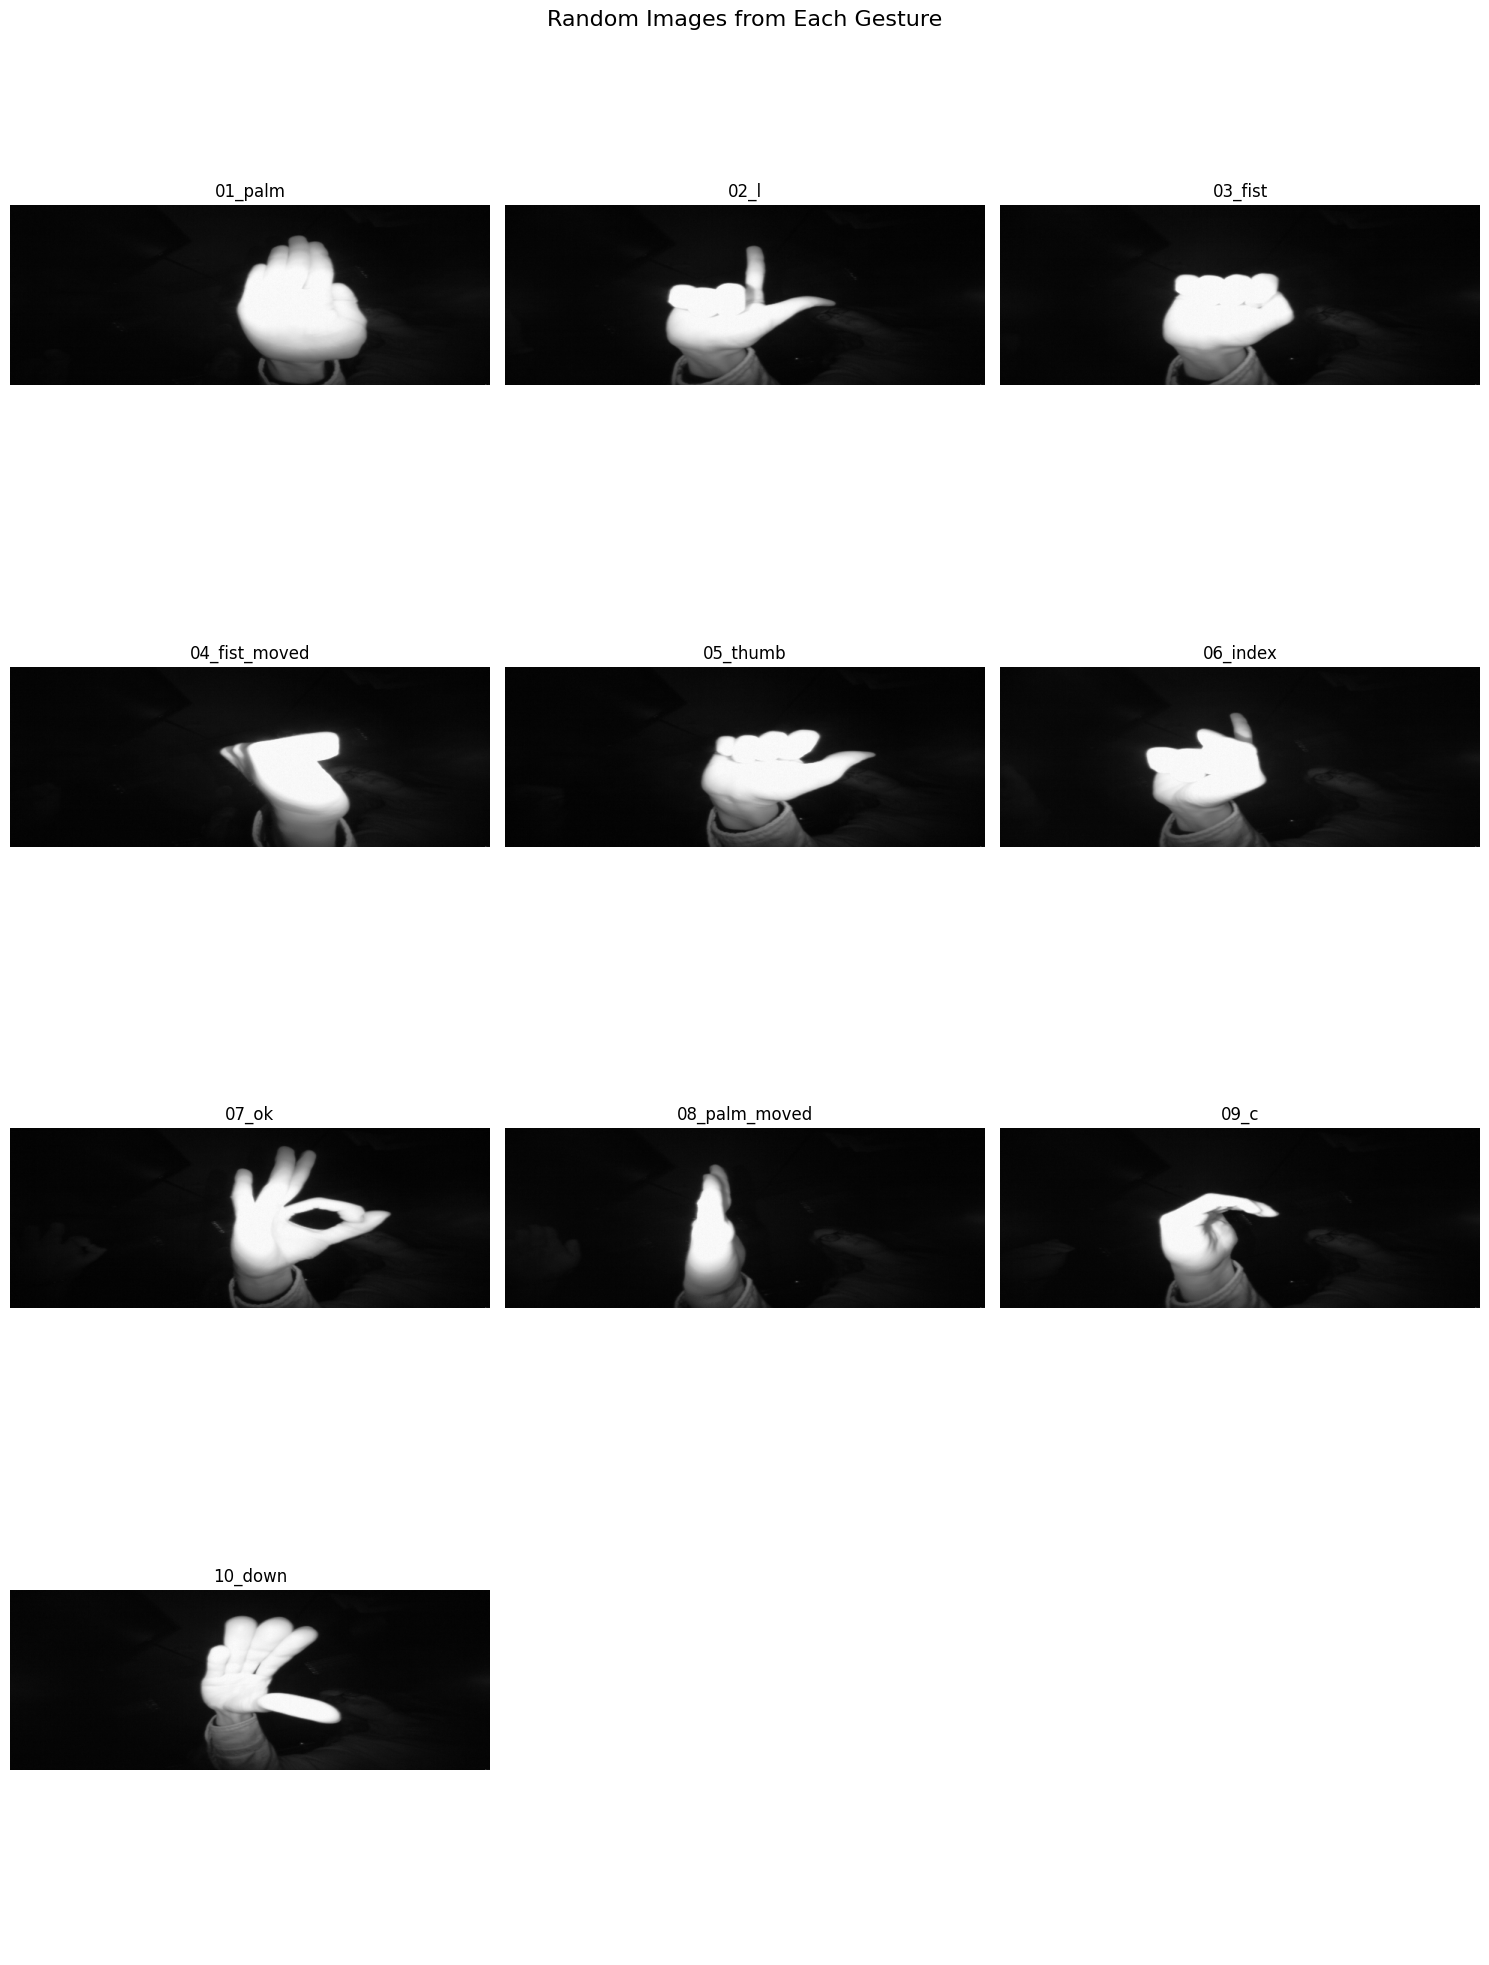

In [4]:
# Initialize a dictionary to store the count of images for each gesture
gesture_counts = {}
# Initialize a dictionary to store one random image path for each gesture
random_images = {}

# Traverse the directory structure
for subject_dir in os.listdir(root_dir):
    subject_path = os.path.join(root_dir, subject_dir)
    if os.path.isdir(subject_path):
        for gesture_dir in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture_dir)
            if os.path.isdir(gesture_path):
                # Get all image files in the gesture directory
                image_files = [f for f in os.listdir(gesture_path) if f.endswith('.png')]
                # Update the count of images for this gesture
                if gesture_dir not in gesture_counts:
                    gesture_counts[gesture_dir] = 0
                gesture_counts[gesture_dir] += len(image_files)
                # Select a random image for this gesture if not already selected
                if gesture_dir not in random_images and image_files:
                    random_image = random.choice(image_files)
                    random_images[gesture_dir] = os.path.join(gesture_path, random_image)

# Display the counts of images for each gesture
print("Gesture Counts:")
for gesture, count in gesture_counts.items():
    print(f"{gesture}: {count} images")

# Plot the random images in a grid
num_gestures = len(random_images)
# Calculate the grid size (rows and columns)
cols = 3  # Number of columns in the grid
rows = (num_gestures + cols - 1) // cols  # Number of rows needed

# Create a figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
fig.suptitle("Random Images from Each Gesture", fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each image in the grid
for i, (gesture, image_path) in enumerate(random_images.items()):
    img = Image.open(image_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(gesture)
    axes[i].axis('off')  # Hide axes

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [5]:
class hand_gesture_data(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image = []
        self.label = []
        
        # Create a dictionary to map folder names to numerical labels
        self.class_to_idx = {}
        folders = os.listdir(root)
        for i, folder in enumerate(folders):
            self.class_to_idx[folder] = i

        for folder in folders:
            for dirpath, dirnames, filenames in os.walk(os.path.join(root, folder)):
                for filename in filenames:
                    self.image.append(os.path.join(dirpath, filename))
                    self.label.append(self.class_to_idx[folder]) # Store numerical label
        self.len = len(self.image)
    
    def __len__(self):
        return self.len

    def __getitem__(self, index):
        img = Image.open(self.image[index]).convert('L')
        y = self.label[index]
        if self.transform:
            img = self.transform(img)
        return img, y

In [6]:
# Load the dataset
dataset = hand_gesture_data(root_dir, transform=transform)

# Split the dataset into 70% training, 15% validation and 15% test
train_size = int(0.7 * len(dataset))
val_size = test_size = (len(dataset) - train_size) // 2

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 14000, Validation: 3000, Test: 3000


In [7]:
class HandGestureClassifier_with_dropout(nn.Module):
    def __init__(self):
        super(HandGestureClassifier_with_dropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)  # BatchNorm for 32 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(0, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)  # BatchNorm for FC layer
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)

        # Dynamically calculate input size for fc1
        if self.fc1.in_features == 0:  
            self.fc1 = nn.Linear(x.size(1), 128) # Set correct input size
            self.fc1.to(device)  # Make sure this new layer is on correct device

        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [ ]:
model = HandGestureClassifier_with_dropout().to(device)
print(model)

# Apply L2 Regularization (Weight Decay)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Add after creating the optimizer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.1,
    patience=3,
    verbose=True
)

# Define the loss function
criterion = nn.CrossEntropyLoss()

num_epochs = 10


HandGestureClassifier_with_dropout(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=0, out_features=128, bias=True)
  (bn_fc1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


c:\CVNL\assignment\CVNL_A1\.venv\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
c:\CVNL\assignment\CVNL_A1\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [9]:
def train(model, train_loader, optimizer, criterion, device, epoch):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)  # Move data to device
        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, targets)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(inputs), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))
        
        running_loss += loss.item()
        
        # Compute accuracy
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    
    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    print(f"Train Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    return avg_loss, accuracy  # Return metrics for logging


In [10]:
def evaluate(model, data_loader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # No gradient computation needed
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            
            # Compute accuracy
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)

    avg_loss = running_loss / len(data_loader)
    accuracy = 100. * correct / total
    print(f"Validation/Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    return avg_loss, accuracy


In [11]:
# Store metrics for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device, epoch)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    print('-' * 40)
    # Store values for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

Epoch 1
Train Epoch: 0 [0/14000 (0%)]	Loss: 2.347133
Train Epoch: 0 [64/14000 (0%)]	Loss: 2.305289
Train Epoch: 0 [128/14000 (1%)]	Loss: 2.324420
Train Epoch: 0 [192/14000 (1%)]	Loss: 2.288729
Train Epoch: 0 [256/14000 (2%)]	Loss: 2.351472
Train Epoch: 0 [320/14000 (2%)]	Loss: 2.293745
Train Epoch: 0 [384/14000 (3%)]	Loss: 2.335448
Train Epoch: 0 [448/14000 (3%)]	Loss: 2.345458
Train Epoch: 0 [512/14000 (4%)]	Loss: 2.183940
Train Epoch: 0 [576/14000 (4%)]	Loss: 2.174154
Train Epoch: 0 [640/14000 (5%)]	Loss: 2.195330
Train Epoch: 0 [704/14000 (5%)]	Loss: 2.130907
Train Epoch: 0 [768/14000 (5%)]	Loss: 2.165150
Train Epoch: 0 [832/14000 (6%)]	Loss: 2.213727
Train Epoch: 0 [896/14000 (6%)]	Loss: 2.095559
Train Epoch: 0 [960/14000 (7%)]	Loss: 2.120678
Train Epoch: 0 [1024/14000 (7%)]	Loss: 2.192554
Train Epoch: 0 [1088/14000 (8%)]	Loss: 2.162627
Train Epoch: 0 [1152/14000 (8%)]	Loss: 2.055239
Train Epoch: 0 [1216/14000 (9%)]	Loss: 2.146829
Train Epoch: 0 [1280/14000 (9%)]	Loss: 2.106221
Tra

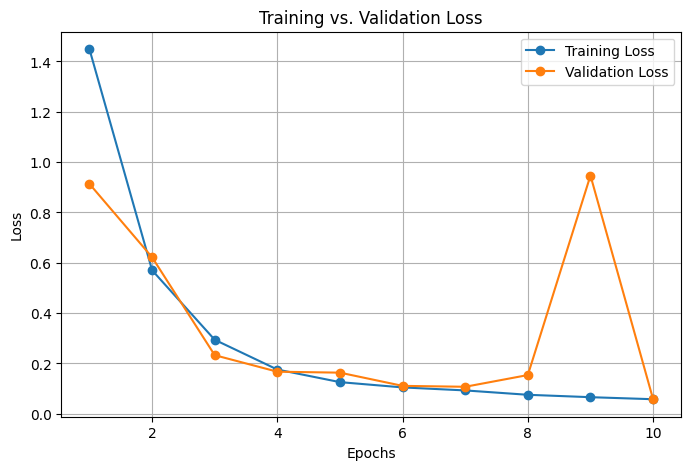

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

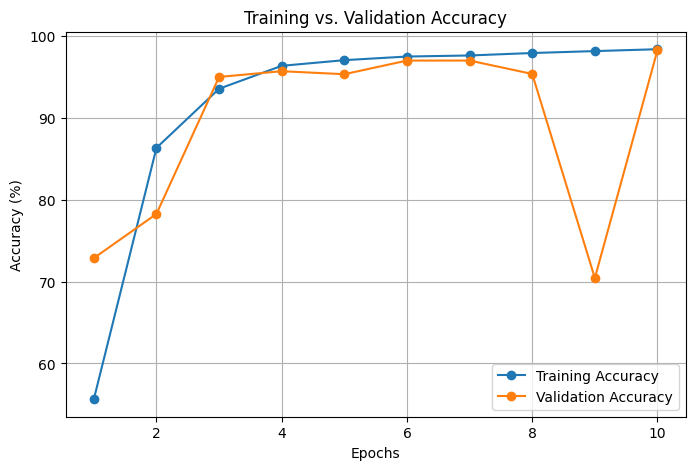

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

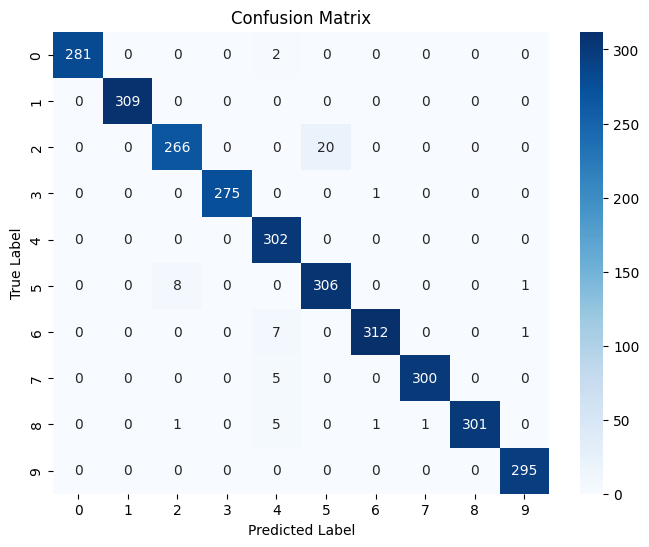

In [14]:
# Get all predictions and labels from the test set
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = [str(i) for i in range(10)]  # Adjust based on your class labels

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Accuracy: {test_acc:.2f}%")

Validation/Test Loss: 0.0660, Accuracy: 97.97%
Final Test Accuracy: 97.97%
